In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve
from matplotlib.lines import Line2D

In [22]:
feature_file_A = "WindFarmA_combined_feature_sensitivity.csv"
feature_file_B = "WindFarmB_combined_feature_sensitivity.csv"
feature_file_C = "WindFarmC_combined_feature_sensitivity.csv"

prediction_file_A = "WindFarmA_combined_prediction_results.csv"
prediction_file_B = "WindFarmB_combined_prediction_results.csv"
prediction_file_C = "WindFarmC_combined_prediction_results.csv"


feat_df_A = pd.read_csv(feature_file_A)
feat_df_B = pd.read_csv(feature_file_B)
feat_df_C = pd.read_csv(feature_file_C)

pred_df_A = pd.read_csv(prediction_file_A)
pred_df_B = pd.read_csv(prediction_file_B)
pred_df_C = pd.read_csv(prediction_file_C)

pred_df_A.columns

Index(['time_stamp', 'asset_id', 'train_test', 'status_type', 'power_avg',
       'avg_wind_speed', 'avg_rotor_speed', 'y_true', 'farm', 'noise_model',
       'y_pred', 'y_prob', 'noise_model.1'],
      dtype='object')

### Precision Recall Curve

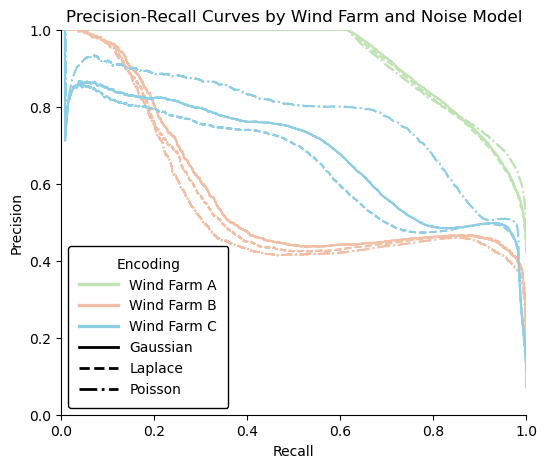

In [23]:
farm_colors = {"A": "#BFE3B4","B": "#F0BFA6","C": "#8ECFE6"}
noise_styles = {"gaussian": "-","laplace": "--","poisson": "-."}
datasets = [("A", pred_df_A),("B", pred_df_B),("C", pred_df_C)]
noise_order = ["gaussian", "laplace", "poisson"]

def make_combined_legend(ax, loc="lower left", title="Encoding"):
    farm_handles = [
        Line2D([0], [0], color=farm_colors[f], lw=2.4, linestyle="-", label=f"Wind Farm {f}")
        for f in ["A", "B", "C"]]
    noise_handles = [
        Line2D([0], [0], color="black", lw=2.0, linestyle=noise_styles[n], label=n.capitalize())
        for n in noise_order]
    handles = farm_handles + noise_handles

    ax.legend(
        handles=handles,
        loc=loc,
        frameon=True,
        edgecolor="black",
        facecolor="white",
        framealpha=1.0,
        borderpad=0.8,
        handlelength=2.8,
        handletextpad=0.8,
        title=title
    )

plt.figure(figsize=(6,5))

for farm_label, df in datasets:
    df = df.copy()
    df["noise_model"] = df["noise_model"].str.lower()
    for noise_type in noise_styles:
        df_sub = df[df["noise_model"] == noise_type]
        if df_sub.empty or df_sub["y_true"].nunique() < 2:
            continue
        y_true = df_sub["y_true"]
        y_prob = df_sub["y_prob"]
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        plt.plot(recall,precision,color=farm_colors[farm_label],linestyle=noise_styles[noise_type])
ax = plt.gca()

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves by Wind Farm and Noise Model")
make_combined_legend(ax, loc="lower left", title="Encoding")

plt.xlim(0,1)
plt.ylim(0,1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

### Time-Series Per Wind Farm

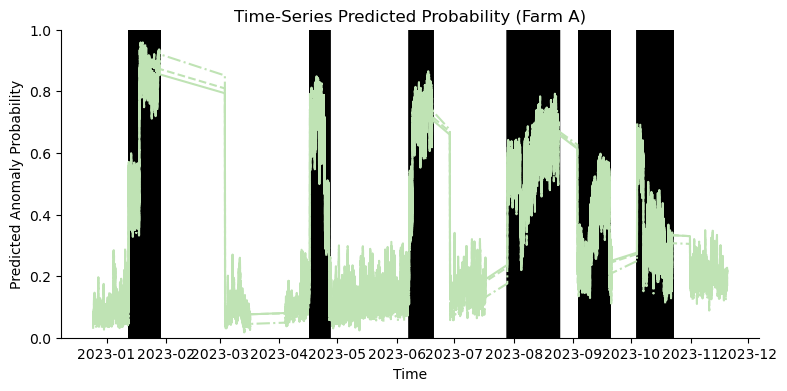

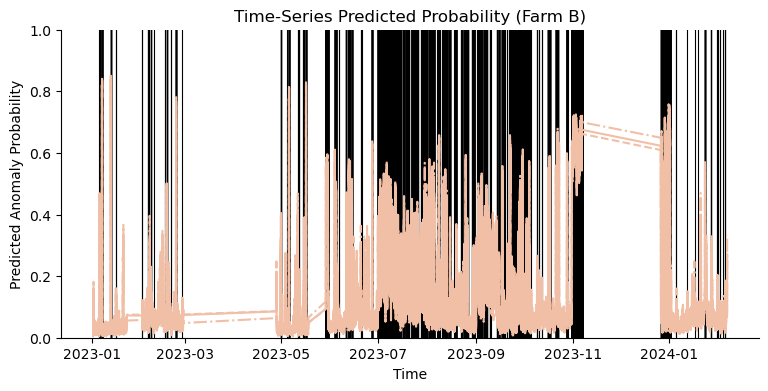

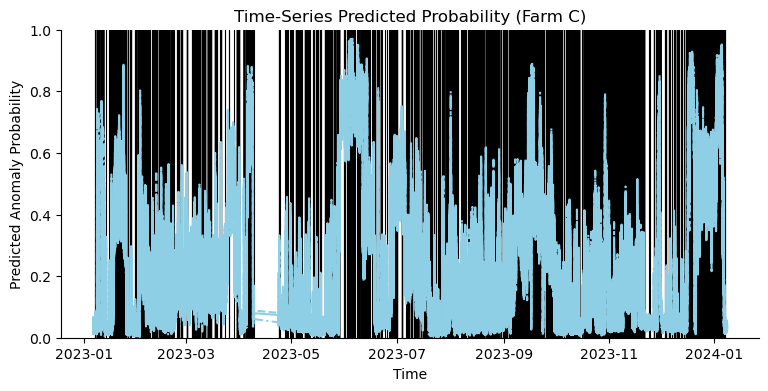

In [24]:
for farm_label, df in datasets:
    df = df.copy()
    df["noise_model"] = df["noise_model"].str.lower()
    if "time_stamp" not in df.columns:
        continue

    df["time_stamp"] = pd.to_datetime(df["time_stamp"])
    df = df.sort_values("time_stamp")

    plt.figure(figsize=(9, 4))
    ax = plt.gca()
    anomaly_times = df.loc[df["y_true"] == 1, "time_stamp"].drop_duplicates()
    for t in anomaly_times:
        ax.axvline(t, color="black", linewidth=0.8)
    for noise_type in noise_order:
        df_sub = df[df["noise_model"] == noise_type].sort_values("time_stamp")

        y_smooth = df_sub["y_prob"].rolling(window=12, min_periods=1).mean()

        ax.plot(
            df_sub["time_stamp"],
            y_smooth,
            color=farm_colors[farm_label],
            linestyle=noise_styles[noise_type],
            label=noise_type.capitalize()
        )
    plt.title(f"Time-Series Predicted Probability (Farm {farm_label})")
    plt.xlabel("Time")
    plt.ylabel("Predicted Anomaly Probability")
    plt.ylim(0, 1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.show()